<a href="https://colab.research.google.com/github/doradosanti/myProjects/blob/main/clustering%2Cassociation_rule_mining%2Censemble_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A: Clustering using K-means

---



Dataset: Iris dataset consisting of measurements of iris flowers (sepal and petal length and width in centimeters) to classify them into distinct clusters

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from collections import Counter
from sklearn import preprocessing
from matplotlib import pyplot as plt

In [ ]:
# Read data
Iris = pd.read_csv("/content/drive/MyDrive/IS470_data/Iris.csv")
Iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,7.9,3.8,6.4,2.0
1,7.7,3.8,6.7,2.2
2,7.7,3.0,6.1,2.3
3,7.7,2.8,6.7,2.0
4,7.7,2.6,6.9,2.3
...,...,...,...,...
145,4.5,2.3,1.3,0.3
146,4.4,3.2,1.3,0.2
147,4.4,3.0,1.3,0.2
148,4.4,2.9,1.4,0.2


In [ ]:
# Examine variable type
Iris.dtypes

,0
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64


In [ ]:
# Create dummy variables
Iris = pd.get_dummies(Iris, drop_first=True, dtype=int)
Iris

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,7.9,3.8,6.4,2.0
1,7.7,3.8,6.7,2.2
2,7.7,3.0,6.1,2.3
3,7.7,2.8,6.7,2.0
4,7.7,2.6,6.9,2.3
...,...,...,...,...
145,4.5,2.3,1.3,0.3
146,4.4,3.2,1.3,0.2
147,4.4,3.0,1.3,0.2
148,4.4,2.9,1.4,0.2


In [ ]:
# Apply minmax normalization
min_max_scaler = preprocessing.MinMaxScaler()
Iris_normalized = pd.DataFrame(min_max_scaler.fit_transform(Iris))
Iris_normalized.columns = Iris.columns
Iris_normalized

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1.000000,0.750000,0.915254,0.791667
1,0.944444,0.750000,0.966102,0.875000
2,0.944444,0.416667,0.864407,0.916667
3,0.944444,0.333333,0.966102,0.791667
4,0.944444,0.250000,1.000000,0.916667
...,...,...,...,...
145,0.055556,0.125000,0.050847,0.083333
146,0.027778,0.500000,0.050847,0.041667
147,0.027778,0.416667,0.050847,0.041667
148,0.027778,0.375000,0.067797,0.041667


###Applying K-means clustering to identify natural groupings in the dataset

In [ ]:
#Clustering model with n_clusters = 3.
model1 = KMeans(n_clusters=3, random_state=0)
model1.fit(Iris_normalized)

KMeans(n_clusters=3, random_state=0)

In [ ]:
# Generate the cluster labels
model1.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
# Show cluster size
Counter(model1.labels_)

Counter({np.int32(2): 39, np.int32(0): 61, np.int32(1): 50})

In [ ]:
# Show cluster centroids
pd.DataFrame({'Versicolor':Iris[model1.labels_==0].mean(axis=0), 'Setosa':Iris[model1.labels_==1].mean(axis=0), 'Virginica':Iris[model1.labels_==2].mean(axis=0)})

,Versicolor,Setosa,Virginica
SepalLengthCm,5.888525,5.006,6.846154
SepalWidthCm,2.737705,3.418,3.082051
PetalLengthCm,4.396721,1.464,5.702564
PetalWidthCm,1.418033,0.244,2.079487


###Selecting an appropiate number of clusters (K) using elbow method

Text(0.5, 1.0, 'Elbow Test')

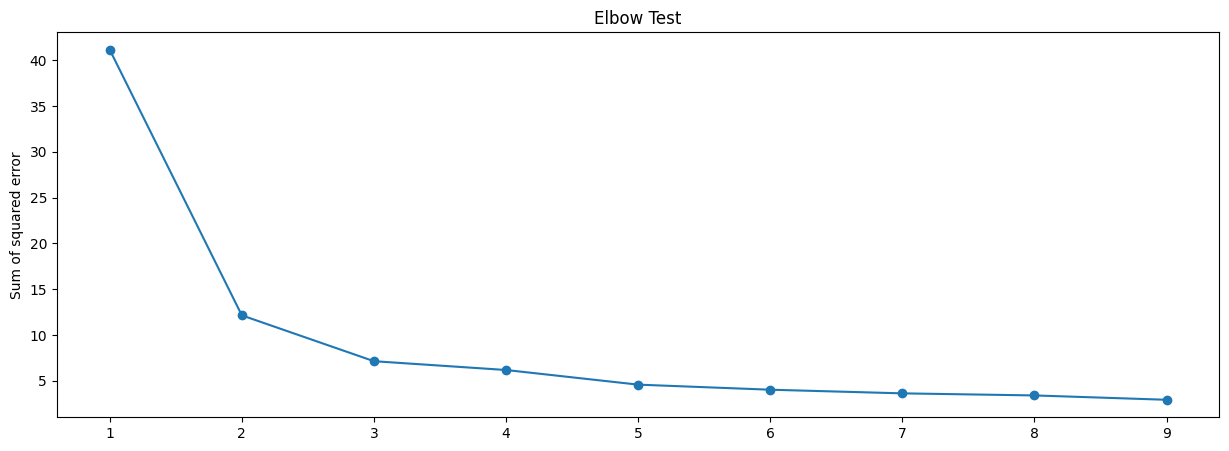

In [ ]:
Sum_of_squared_error = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(Iris_normalized)
    Sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.scatter(range(1, 10), Sum_of_squared_error)
plt.plot(range(1, 10), Sum_of_squared_error)
plt.ylabel('Sum of squared error')
plt.title('Elbow Test')

The optimal number of clusters = 3. After k=3 the curve begins to flatten meaning more clusters after that would not have significance.

###Labeling the clusters

Determining which cluster corresponds to which species.

*   Iris-setosa: Have distinctively shorter petals and narrow Sepal width compared to the other species. Therefore, cluster 2 would be iris-setosa because the petal length (1.46) and petal width (0.24) is significantly smaller.
*   Iris-versicolor: This species is more moderate size compared to the larger Virginica. Therefore, cluster 1 should be iris-versicolor because in terms of length and widths is lies in between cluster 2 being smaller and cluster 3 being larger in size.
*   Iris-virginica: Lastly, this species (cluster 3) has the largest petals and sepals of the three main iris species.



#Part B: Association Rule Mining using Apriori

---



Dataset: Online Retail Transactions containing items purchased by customers from an online retailer to mine association rules.

In [ ]:
# Import libraries
! pip install apyori
import pandas as pd
import numpy as np
from csv import reader
import seaborn as sns
from apyori import apriori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=9ed755198cff06c61dc55432de56ba23fe1738dde0368d5261fbc69fc4cb3471
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
# Read data line by line
retailTrans = []
with open('/content/drive/MyDrive/IS470_data/OnlineRetailTransactions.csv', 'r') as read_obj:
    csv_reader = reader(read_obj)
    for row in csv_reader:
        retailTrans.append(row)

In [ ]:
# Inspect the first 5 transactions
retailTrans[:5]

[['white hanging heart t-light holder',
  ' white metal lantern',
  ' cream cupid hearts coat hanger',
  ' knitted union flag hot water bottle',
  ' red woolly hottie white heart.',
  ' set 7 babushka nesting boxes',
  ' glass star frosted t-light holder'],
 ['hand warmer union jack', ' hand warmer red polka dot'],
 ['assorted colour bird ornament',
  " poppy's playhouse bedroom ",
  " poppy's playhouse kitchen",
  ' feltcraft princess charlotte doll',
  ' ivory knitted mug cosy ',
  ' box of 6 assorted colour teaspoons',
  ' box of vintage jigsaw blocks ',
  ' box of vintage alphabet blocks',
  ' home building block word',
  ' love building block word',
  ' recipe box with metal heart',
  ' doormat new england'],
 ['jam making set with jars',
  ' red coat rack paris fashion',
  ' yellow coat rack paris fashion',
  ' blue coat rack paris fashion'],
 ['bath building block word']]

In [ ]:
# Show the number of unique items
flat_list = np.concatenate(retailTrans).flat
unique_item, item_count = np.unique(flat_list, return_counts=True)
print("number of unique items:", len(unique_item))

number of unique items: 7061


In [ ]:
# Show the number of transactions
len(retailTrans)

25900

In [ ]:
# Examine the absolute frquency of items in descending order
item_frequency = pd.DataFrame({'items':flat_list})
item_frequency.value_counts()

,count
items,
white hanging heart t-light holder,2163
jumbo bag red retrospot,2056
regency cakestand 3 tier,1911
party bunting,1598
lunch bag red retrospot,1557
...,...
wrongly coded 23343,1
wrong code?,1
wrong code,1


Top 3 most frequent items in the dataset are 'white hanging heart t-light holder', 'jumbo bag red retrospot', 'regency cakestand 3 tier'.

In [ ]:
# Examine the relative frquency of items in descending order
item_frequency.value_counts()/len(retailTrans)

,count
items,
white hanging heart t-light holder,0.083514
jumbo bag red retrospot,0.079382
regency cakestand 3 tier,0.073784
party bunting,0.061699
lunch bag red retrospot,0.060116
...,...
wrongly coded 23343,0.000039
wrong code?,0.000039
wrong code,0.000039



*   White hanging heart t-light holder appears in 8.35% of tansactions
*   Jumbo bag red retrospot appears in about 7.94% of transactions.
*   Regency cakestand 3 tier appears in about 7.38% of all transactions.


###Implementing Apriori algorithm to discover frequent itemsets and associated rules.

Because the online retail dataset is large (25,000+ transactions), I used a higher minimum confidence treshold to reduce noise and overwhelming number of rules, many of which would be weak and redundant.

In [ ]:
# Use the apriori command to generate rules
Transaction_rules = apriori(retailTrans, min_support = 0.01, min_confidence = 0.7, max_length=3)
Transaction_rules = list(Transaction_rules)

In [ ]:
# Display all rules
all_rules = pd.DataFrame(columns=('LHS','RHS','support','confidence','lift'))
for i in range(len(Transaction_rules)):
  for rule_ in Transaction_rules[i].ordered_statistics:
    #all_rules = all_rules.append({'LHS':','.join(list(rule_.items_base)),'RHS':','.join(list(rule_.items_add)), 'support': groceries_rules[i].support, 'confidence': rule_.confidence, 'lift': rule_.lift}, ignore_index=True)
    all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [Transaction_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)
pd.options.display.max_rows = 999
all_rules

/tmp/ipython-input-1534510519.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_rules = pd.concat([all_rules, pd.DataFrame({'LHS':[','.join(list(rule_.items_base))],'RHS':[','.join(list(rule_.items_add))], 'support': [Transaction_rules[i].support], 'confidence': [rule_.confidence], 'lift': [rule_.lift]})],ignore_index=True)


,LHS,RHS,support,confidence,lift
0,airline lounge,metal sign,0.011158,1.000000,88.395904
1,metal sign,airline lounge,0.011158,0.986348,88.395904
2,back door,key fob,0.011853,0.990323,49.136695
3,toilet metal sign,bathroom metal sign,0.011120,0.712871,29.400265
4,retro spot,birthday card,0.010270,0.985185,61.932758
5,pink regency teacup and saucer,green regency teacup and saucer,0.023320,0.801061,20.380629
6,green regency teacup and saucer,roses regency teacup and saucer,0.028031,0.713163,17.658627
7,key fob,shed,0.014324,0.710728,49.087612
8,shed,key fob,0.014324,0.989333,49.087612
9,pink regency teacup and saucer,roses regency teacup and saucer,0.021737,0.746684,18.488647


In [ ]:
# Display all rules sorted by lift levels
all_rules.sort_values(by ='lift', ascending = False)

,LHS,RHS,support,confidence,lift
0,airline lounge,metal sign,0.011158,1.000000,88.395904
1,metal sign,airline lounge,0.011158,0.986348,88.395904
4,retro spot,birthday card,0.010270,0.985185,61.932758
12,regency tea plate green,regency tea plate pink,0.010386,0.719251,61.077409
13,regency tea plate pink,regency tea plate green,0.010386,0.881967,61.077409
65,"coffee, set 3 retrospot tea",sugar,0.016332,1.000000,58.863636
64,sugar,"coffee, set 3 retrospot tea",0.016332,0.961364,58.863636
18,sugar,set 3 retrospot tea,0.016332,0.961364,58.863636
17,set 3 retrospot tea,sugar,0.016332,1.000000,58.863636
62,set 3 retrospot tea,"coffee,sugar",0.016332,1.000000,58.863636


###Interpret top five generated rules based on their lift, and explain their significance in terms of potential business insights.

In [ ]:
# Display the top 5 rules sorted by lift levels
all_rules.sort_values(by ='lift', ascending = False)[:5]

,LHS,RHS,support,confidence,lift
0,airline lounge,metal sign,0.011158,1.000000,88.395904
1,metal sign,airline lounge,0.011158,0.986348,88.395904
4,retro spot,birthday card,0.010270,0.985185,61.932758
12,regency tea plate green,regency tea plate pink,0.010386,0.719251,61.077409
13,regency tea plate pink,regency tea plate green,0.010386,0.881967,61.077409




1.   Airline lounge (LHS), metal sign (RHS):

*   Purchasing 'airline lounge' increases the probability of buying whole milk by 88.4 times.


2.   Metal sign (LHS), airline loung (RHS):

*   In comparison to the first rule, purchasing a metal sign increases the probability of buying airline lounge by 88.4 times.


3.   Retro spot (LHS), birthday card (RHS):

*   Purchasing retro spot increases the probability of buying a birthday card by 62 times.


4.   Regency tea plate green (LHS), regency tea plate pink (RHS):

*   Purchasing a regency green tea plate increases the probability of buying a pink one by 61 times.


5.   Regency tea plate pink (LHS), regency tea plate green (RHS):

*   Like rule 4, purchasing a regency pink tea plate increases the probability of buying a green one by 61 times.

In a business context, the strong association between airline lounge and metal sign, and regency green and pink tea plate means that these items should be placed together in category and advertise them as frequently bought together. As for the the retro and card rule these items should be promoted together during holidays and birthdays.






#Part C: Ensemble Models

---



Dataset: Titanic dataset for classification to answer, "what sorts of people were more likely to survive the sinking of the Titanic?" using passenger data (i.e., name, age, gender, socio-economic class, etc)

Target Variable:<br>
Survival 0 = No, 1 = Yes

Variable definitions:

*   Pclass: Ticket classes (1st, 2nd, 3rd)

*   Sibsp: number of siblings / spouses aboard the Titanic

*   Parch: number of parents / children aboard the Titanic

*   Embarked: port of embarkation (Charbourg, Queenstown, Southampton)

In [ ]:
# Import libraries
import pandas as pd
from sklearn import preprocessing
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression # Try to use this in the exercise
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import linear_model

In [ ]:
# Read data
titanic = pd.read_csv("/content/drive/MyDrive/IS470_data/Titanic.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.0708,NaN,C


In [ ]:
# Examine missing values
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Set missing values as none
titanic = titanic.fillna('None')

In [ ]:
# Examine missing values again
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Remove the unique identifier
titanic = titanic.drop(['PassengerId'],axis=1)
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
5,0,3,"Moran, Mr. James",male,None,0,0,330877,8.4583,None,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,None,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,None,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,None,C


In [ ]:
# Replacing 1 with Yes and 0 with No in the target column IsBadBuy
titanic = titanic.copy() #why?
titanic.loc[:, 'Survived'] = titanic['Survived'].replace({0: 'No', 1: 'Yes'})

/tmp/ipython-input-3457653575.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'No'
 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No'
 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 

In [ ]:
# Examine variable type
titanic.dtypes

,0
Survived,object
Pclass,int64
Name,object
Sex,object
Age,object
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [ ]:
# Change categorical variables to "category"
titanic['Survived'] = titanic['Survived'].astype('category')
titanic['Name'] = titanic['Name'].astype('category')
titanic['Sex'] = titanic['Sex'].astype('category')
titanic['Age'] = titanic['Age'].astype('category')
titanic['Ticket'] = titanic['Ticket'].astype('category')
titanic['Cabin'] = titanic['Cabin'].astype('category')
titanic['Embarked'] = titanic['Embarked'].astype('category')

Text(0.5, 1.0, 'countplot of target variable')

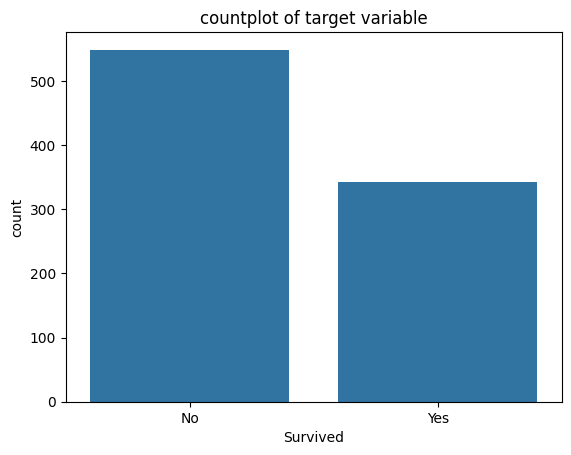

In [ ]:
# Plot of target variable
snsplot = sns.countplot(x='Survived', data=titanic)
snsplot.set_title("countplot of target variable")

In [ ]:
# Create dummy variables
titanic = pd.get_dummies(titanic, columns=['Name','Sex','Age','Ticket', 'Cabin', 'Embarked'], drop_first=True)
titanic

,Survived,Pclass,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin",...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_None,Cabin_T,Embarked_None,Embarked_Q,Embarked_S
0,No,3,1,0,7.2500,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,Yes,1,1,0,71.2833,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Yes,3,0,0,7.9250,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,Yes,1,1,0,53.1000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,No,3,0,0,8.0500,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
5,No,3,0,0,8.4583,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
6,No,1,0,0,51.8625,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,No,3,3,1,21.0750,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
8,Yes,3,0,2,11.1333,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
9,Yes,2,1,0,30.0708,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Partition the data
target = titanic['Survived']
predictors = titanic.drop(['Survived'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(623, 1813) (268, 1813) (623,) (268,)


In [ ]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize=True))

Survived
No     0.611557
Yes    0.388443
Name: proportion, dtype: float64


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

Survived
No     0.626866
Yes    0.373134
Name: proportion, dtype: float64


###Implement ensemble models: Voting, Bagging, and Boosting approaches (all three approaches are required)

####Voting

In [ ]:
# Create learners
estimators = []
learner_1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
estimators.append(("Decision_Tree", learner_1))
learner_2 = SVC(C=5)
estimators.append(("SVM", learner_2))
estimators = []
learner_3 = MLPClassifier(hidden_layer_sizes=(50), random_state=1, max_iter=300)
estimators.append(("MLPC", learner_3))
learner_4 = LogisticRegression(solver='liblinear')
estimators.append(("LogReg", learner_4))

In [ ]:
# Create a voting model
model1_voting = VotingClassifier(estimators, voting="soft")
model1_voting.fit(predictors_train, target_train)

VotingClassifier(estimators=[('MLPC',
                              MLPClassifier(hidden_layer_sizes=50, max_iter=300,
                                            random_state=1)),
                             ('LogReg',
                              LogisticRegression(solver='liblinear'))],
                 voting='soft')

In [ ]:
# Make predictions on testing data
prediction_on_test = model1_voting.predict(predictors_test)

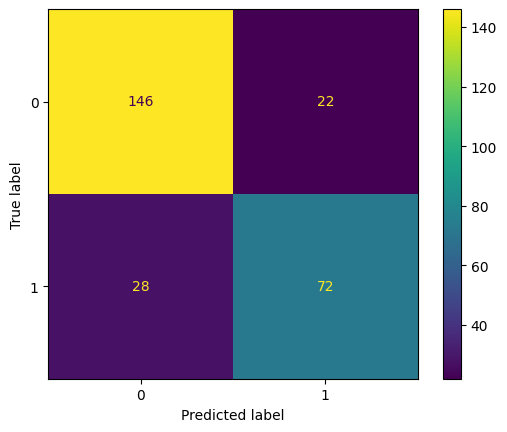

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.84      0.87      0.85       168
         Yes       0.77      0.72      0.74       100

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



In [ ]:
# Create three learners
estimators = []
learner_1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 4)
estimators.append(("Decision_Tree", learner_1))
learner_2 = LogisticRegression(solver='liblinear')
estimators.append(("LogReg", learner_2))
learner_3 = KNeighborsClassifier(n_neighbors=7)
estimators.append(("KNN", learner_3))

In [ ]:
# Create a voting model
model_voting = VotingClassifier(estimators)
model_voting.fit(predictors_train, target_train)

VotingClassifier(estimators=[('Decision_Tree',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=4,
                                                     random_state=1)),
                             ('LogReg', LogisticRegression(solver='liblinear')),
                             ('KNN', KNeighborsClassifier(n_neighbors=7))])

In [ ]:
# Make predictions on testing data
prediction_on_test = model_voting.predict(predictors_test)

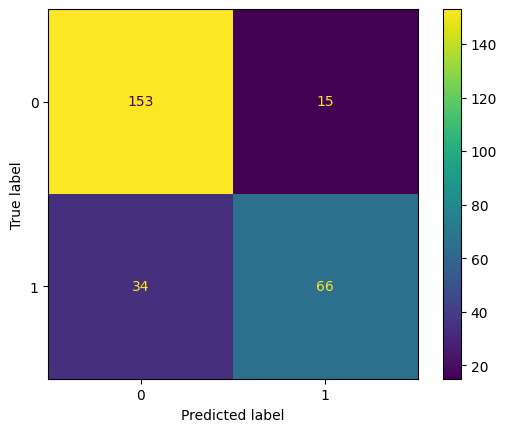

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.82      0.91      0.86       168
         Yes       0.81      0.66      0.73       100

    accuracy                           0.82       268
   macro avg       0.82      0.79      0.80       268
weighted avg       0.82      0.82      0.81       268



####Bagging

In [ ]:
# Bagging based on decision tree model
model_bagging = BaggingClassifier(estimator=DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3), n_estimators=20, random_state=1)
model_bagging.fit(predictors_train, target_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=3,
                                                   random_state=1),
                  n_estimators=20, random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_bagging.predict(predictors_test)

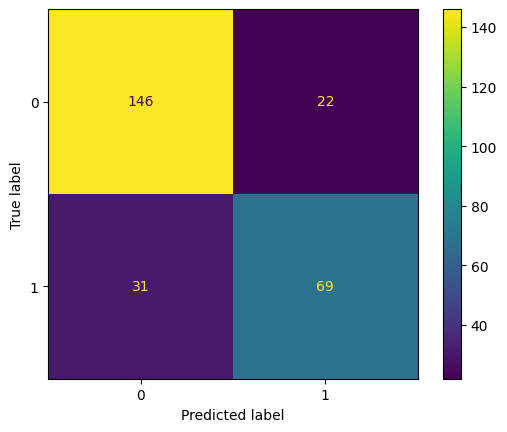

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.82      0.87      0.85       168
         Yes       0.76      0.69      0.72       100

    accuracy                           0.80       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.80      0.80      0.80       268



In [ ]:
# Bagging based on decision tree model
model2_bagging = BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=7), n_estimators=20, random_state=1)
model2_bagging.fit(predictors_train, target_train)

BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=7),
                  n_estimators=20, random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model2_bagging.predict(predictors_test)

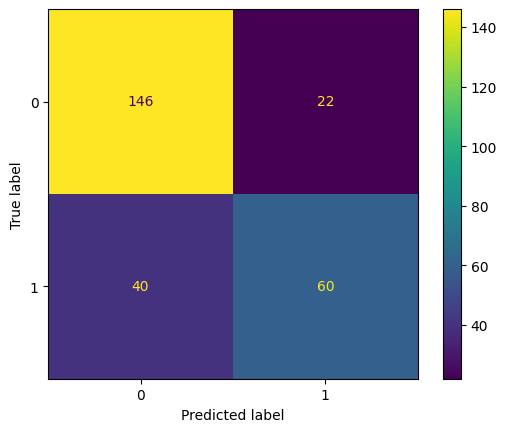

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.78      0.87      0.82       168
         Yes       0.73      0.60      0.66       100

    accuracy                           0.77       268
   macro avg       0.76      0.73      0.74       268
weighted avg       0.77      0.77      0.76       268



####Boosting

In [ ]:
# Bagging based on decision tree model
model1_Boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3), n_estimators=10, random_state=1)
model1_Boost.fit(predictors_train, target_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=3,
                                                    random_state=1),
                   n_estimators=10, random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model1_Boost.predict(predictors_test)

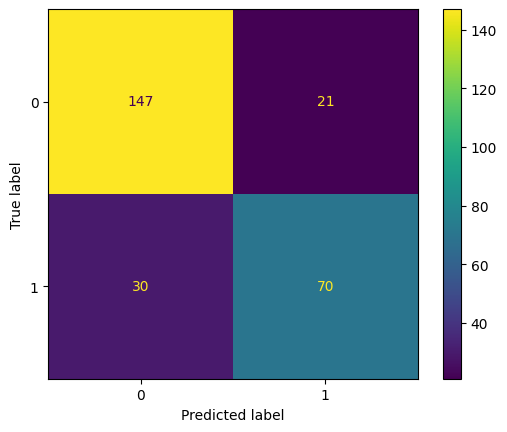

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.83      0.88      0.85       168
         Yes       0.77      0.70      0.73       100

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.81      0.81      0.81       268



In [ ]:
# Bagging based on decision tree model
model_Boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 1), n_estimators=200, random_state=42)
model_Boost.fit(predictors_train, target_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=1,
                                                    random_state=1),
                   n_estimators=200, random_state=42)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_Boost.predict(predictors_test)

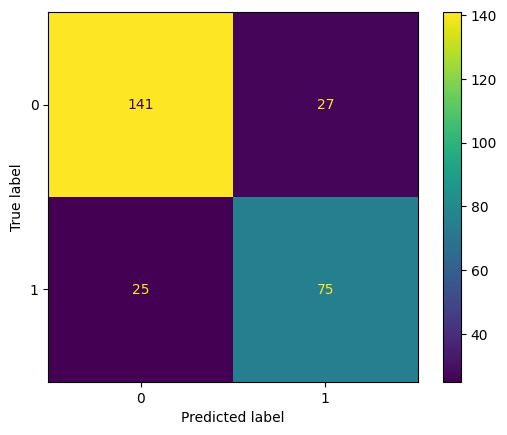

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.85      0.84      0.84       168
         Yes       0.74      0.75      0.74       100

    accuracy                           0.81       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.81      0.81      0.81       268



###Try three single models (i.e., decision tree, naïve bayes, KNN, logistic regression, SVM, and MLP)

####Decision Tree

In [ ]:
# Build a decision tree model on training data with max_depth = 3
modelDT = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
modelDT.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

[Text(0.5, 0.875, 'Sex_male <= 0.5\nentropy = 0.964\nsamples = 623\nvalue = [381, 242]\nclass = No'),
 Text(0.25, 0.625, 'Pclass <= 2.5\nentropy = 0.806\nsamples = 215\nvalue = [53, 162]\nclass = Yes'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Cabin_C22 C26 <= 0.5\nentropy = 0.349\nsamples = 122\nvalue = [8, 114]\nclass = Yes'),
 Text(0.0625, 0.125, 'entropy = 0.286\nsamples = 120\nvalue = [6, 114]\nclass = Yes'),
 Text(0.1875, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = No'),
 Text(0.375, 0.375, 'Fare <= 23.35\nentropy = 0.999\nsamples = 93\nvalue = [45, 48]\nclass = Yes'),
 Text(0.3125, 0.125, 'entropy = 0.954\nsamples = 72\nvalue = [27, 45]\nclass = Yes'),
 Text(0.4375, 0.125, 'entropy = 0.592\nsamples = 21\nvalue = [18, 3]\nclass = No'),
 Text(0.75, 0.625, 'Cabin_None <= 0.5\nentropy = 0.714\nsamples = 408\nvalue = [328, 80]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Age_None <= 0.5\nentropy = 0.971\nsamples = 80\nvalue = [48, 32]\n

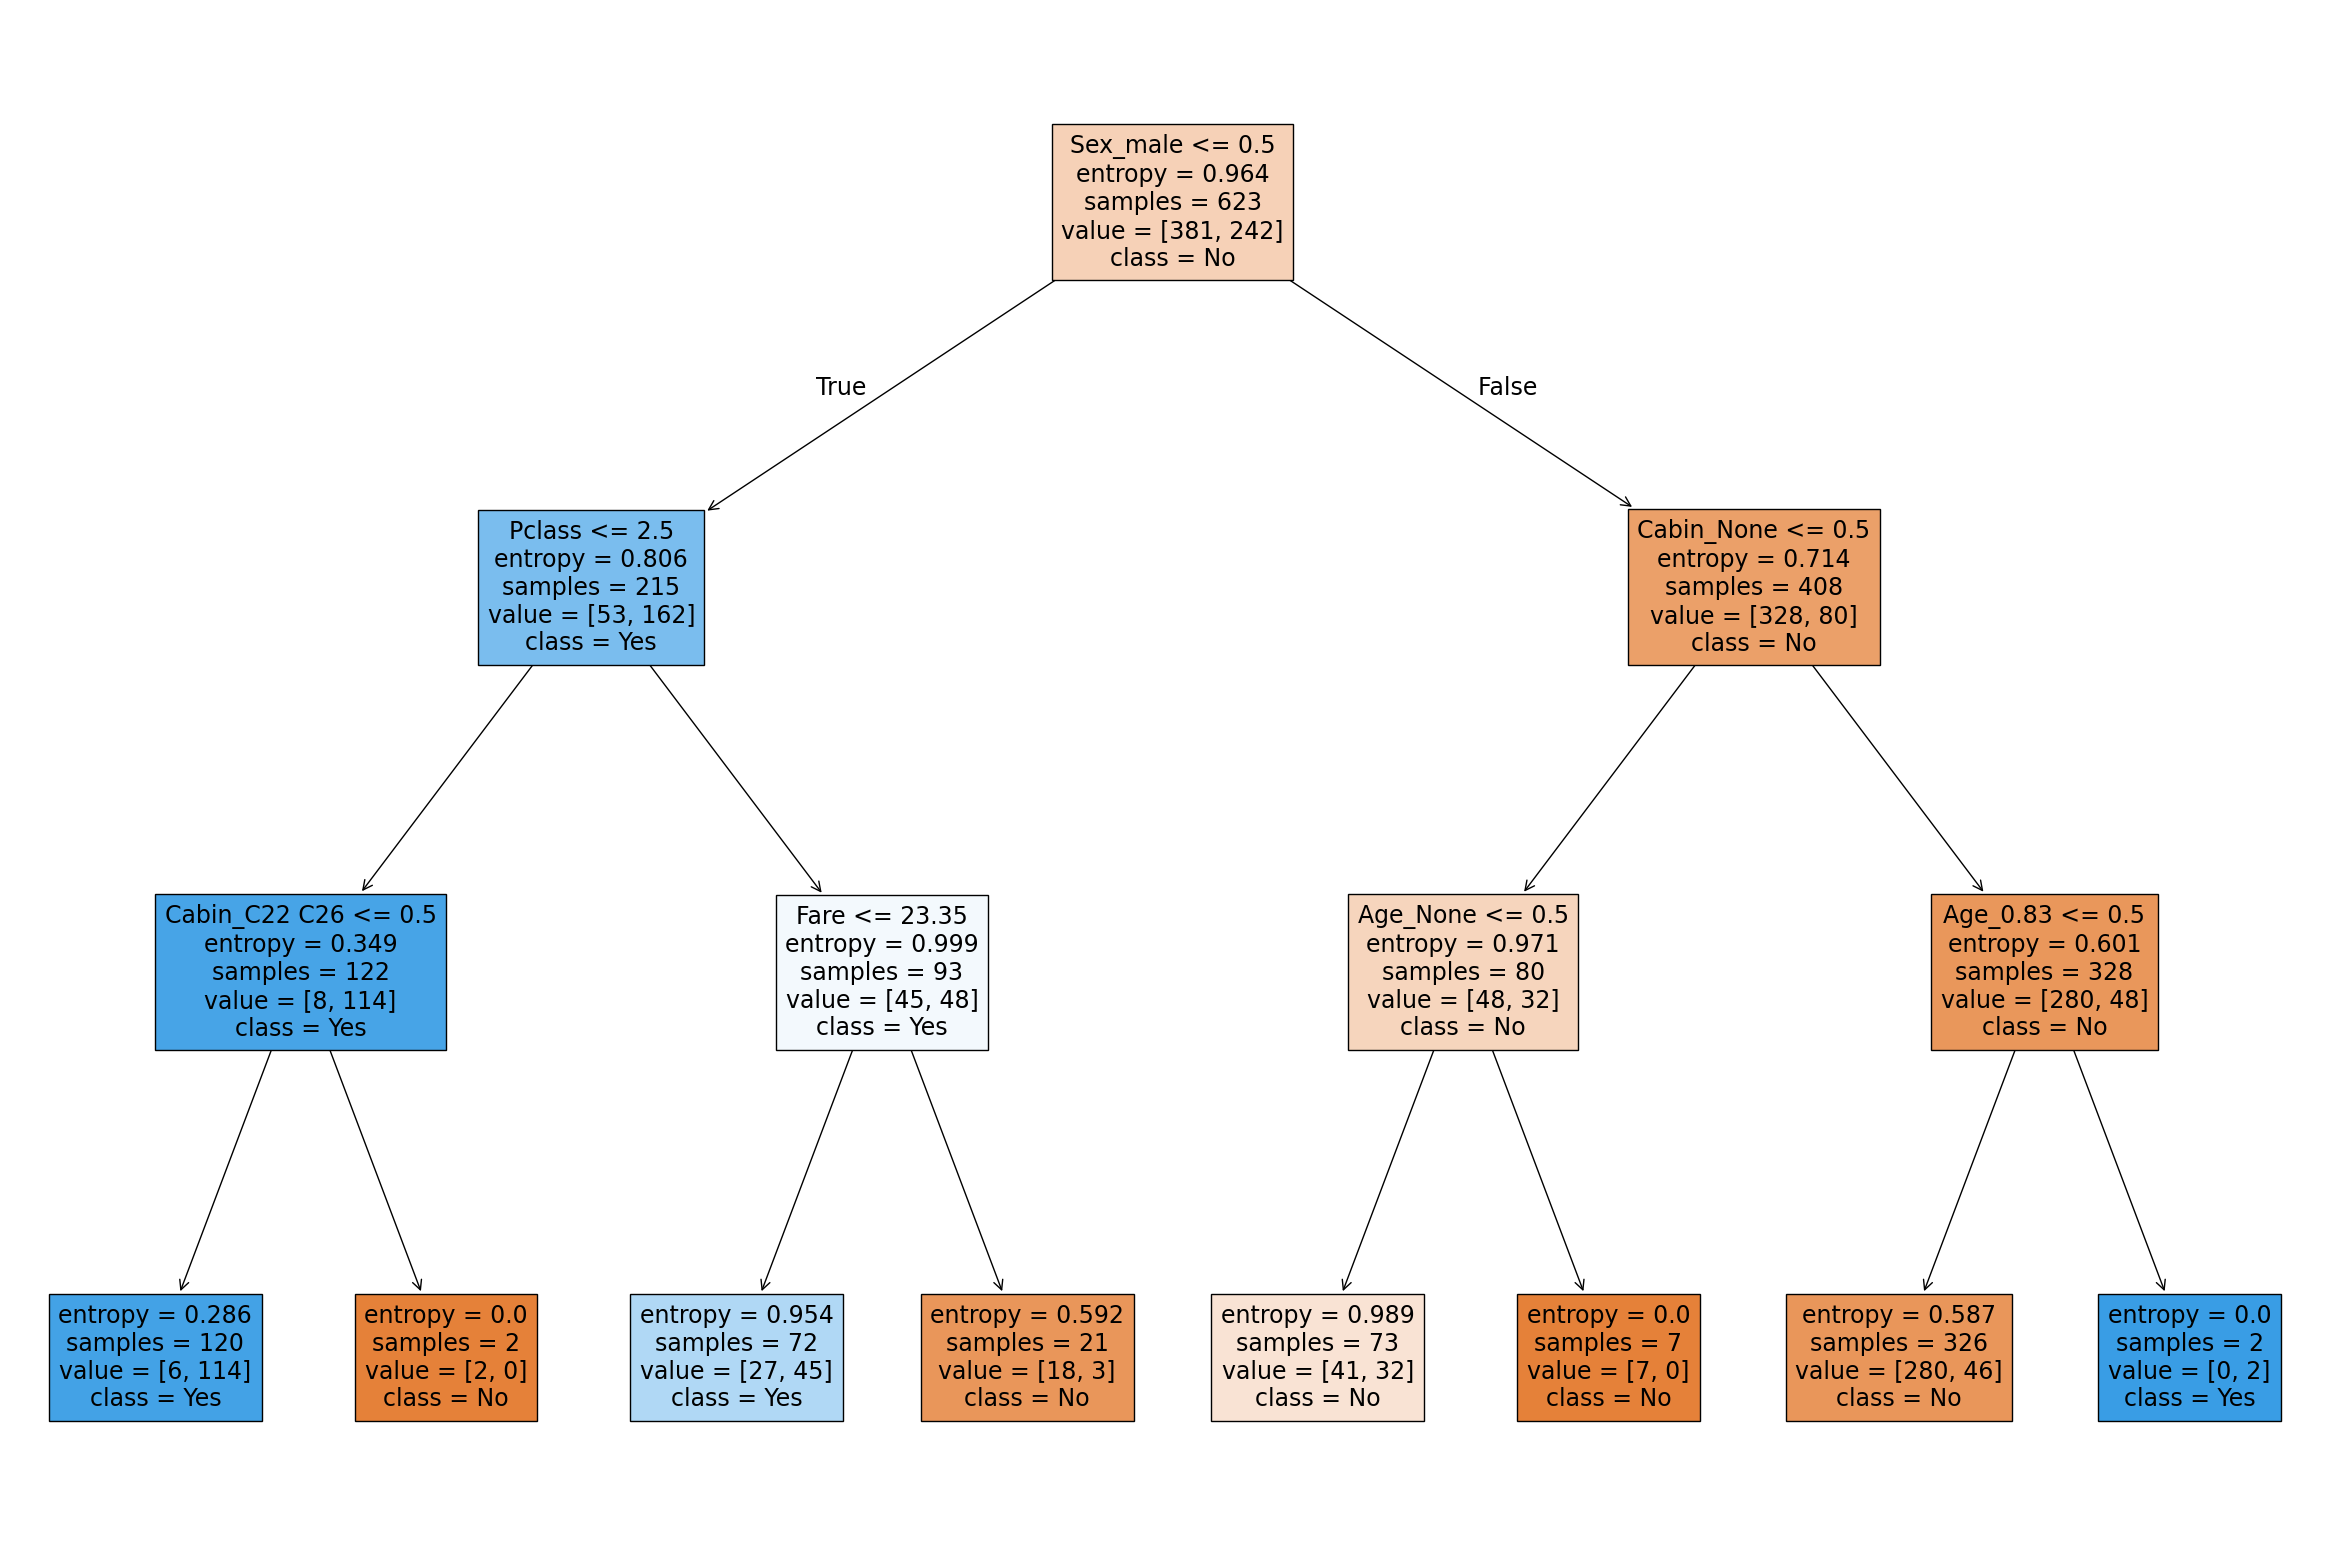

In [ ]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(modelDT,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [ ]:
# Make predictions on testing data
prediction_on_test = modelDT.predict(predictors_test)

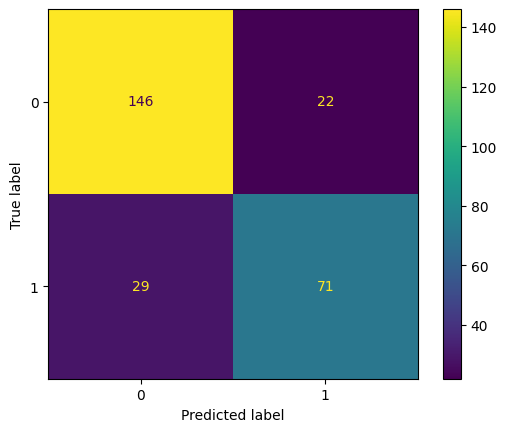

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.83      0.87      0.85       168
         Yes       0.76      0.71      0.74       100

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.81      0.81      0.81       268



####KNN

In [ ]:
# Apply minmax normalization on predictors
min_max_scaler = preprocessing.MinMaxScaler()
predictors_normalized = pd.DataFrame(min_max_scaler.fit_transform(predictors))
predictors_normalized.columns = predictors.columns
predictors_normalized

,Pclass,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin","Name_Adams, Mr. John",...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_None,Cabin_T,Embarked_None,Embarked_Q,Embarked_S
0,1.0,0.125,0.000000,0.014151,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.125,0.000000,0.139136,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.000,0.000000,0.015469,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.125,0.000000,0.103644,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.000,0.000000,0.015713,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,1.0,0.000,0.000000,0.016510,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,0.0,0.000,0.000000,0.101229,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,1.0,0.375,0.166667,0.041136,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,1.0,0.000,0.333333,0.021731,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,0.5,0.125,0.000000,0.058694,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Taking steps to balance the train data
# Combine predictors_train and target_train into a single DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
majority_df = combined_train_df[combined_train_df['Survived'] == 'No']
minority_df = combined_train_df[combined_train_df['Survived'] == 'Yes']
#print(len(majority_df), len(minority_df))
# Undersample the majority class randomly
undersampled_majority = majority_df.sample(n=int(1*len(minority_df)), random_state=55)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame to ensure randomness
balanced_data = undersampled_data.sample(frac=1, random_state=1)

# Split the balanced_data into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['Survived'])
target_train = balanced_data['Survived']

In [ ]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize=True))

Survived
No     0.5
Yes    0.5
Name: proportion, dtype: float64


In [ ]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

Survived
No     0.626866
Yes    0.373134
Name: proportion, dtype: float64


In [ ]:
# Build a K Nearest Neighbor model on training data with n_neighbors = 1 (1 points)
modelKNN = KNeighborsClassifier(n_neighbors = 6)
modelKNN.fit(predictors_train, target_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
# Make predictions on training and testing data
prediction_on_train = modelKNN.predict(predictors_train)
prediction_on_test = modelKNN.predict(predictors_test)

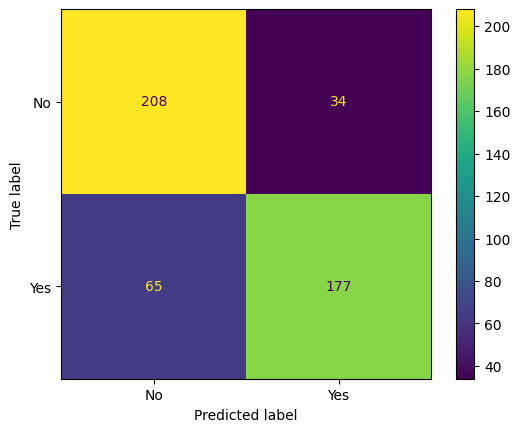

In [ ]:
# Examine the evaluation results on training data: confusion_matrix
cm = confusion_matrix(target_train, prediction_on_train)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelKNN.classes_).plot()

In [ ]:
# Examine the evaluation results on training data: accuracy, precision, recall, and f1-score
print(classification_report(target_train , prediction_on_train ))

              precision    recall  f1-score   support

          No       0.76      0.86      0.81       242
         Yes       0.84      0.73      0.78       242

    accuracy                           0.80       484
   macro avg       0.80      0.80      0.79       484
weighted avg       0.80      0.80      0.79       484



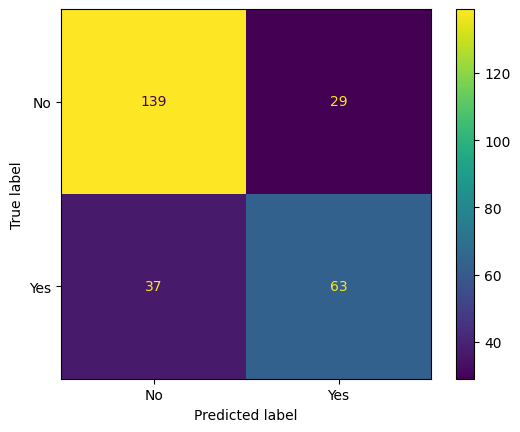

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelKNN.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.79      0.83      0.81       168
         Yes       0.68      0.63      0.66       100

    accuracy                           0.75       268
   macro avg       0.74      0.73      0.73       268
weighted avg       0.75      0.75      0.75       268




####MLPClassifier

In [ ]:
#Build MLP model contains hidden layers
model_MLPC = MLPClassifier(hidden_layer_sizes=(64,16,8), random_state=1)
model_MLPC.fit(predictors_train, target_train)

MLPClassifier(hidden_layer_sizes=(64, 16, 8), random_state=1)

In [ ]:
# Make predictions on testing data
prediction_on_test = model_MLPC.predict(predictors_test)

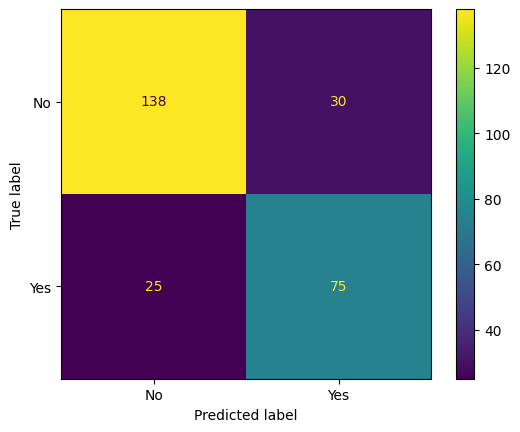

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_MLPC.classes_).plot()

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.85      0.82      0.83       168
         Yes       0.71      0.75      0.73       100

    accuracy                           0.79       268
   macro avg       0.78      0.79      0.78       268
weighted avg       0.80      0.79      0.80       268



###Compare results with a tableof all the models’ performance. What is the best model performance.

In [ ]:
results = []

def add_model_results(name, model):
    y_pred = model.predict(predictors_test)
    report = classification_report(target_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_weighted": report["weighted avg"]["precision"],
        "Recall_weighted": report["weighted avg"]["recall"],
        "F1_weighted": report["weighted avg"]["f1-score"],
        "F1_macro": report["macro avg"]["f1-score"]
    })


add_model_results("Decision Tree", modelDT)
add_model_results("KNN", modelKNN)
add_model_results("MLPClassifier", model_MLPC)

add_model_results("Voting Ensemble", model1_voting)
add_model_results("Voting Ensemble #2", model_voting)
add_model_results("Boosting Ensemble", model_bagging)
add_model_results("Boosting Ensemble #2", model2_bagging)
add_model_results("Bagging Ensemble", model1_Boost)
add_model_results("Bagging Ensemble #2", model_Boost)


results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro
0,Decision Tree,0.809701,0.807851,0.809701,0.808192,0.793532
1,KNN,0.753731,0.750597,0.753731,0.751464,0.732195
2,MLPClassifier,0.794776,0.797245,0.794776,0.795729,0.782772
3,Voting Ensemble,0.805970,0.806822,0.805970,0.806350,0.793443
4,Voting Ensemble #2,0.817164,0.816925,0.817164,0.812461,0.795627
5,Boosting Ensemble,0.802239,0.800002,0.802239,0.800159,0.784445
6,Boosting Ensemble #2,0.768657,0.765081,0.768657,0.763098,0.742100
7,Bagging Ensemble,0.809701,0.807644,0.809701,0.807700,0.792579
8,Bagging Ensemble #2,0.805970,0.806822,0.805970,0.806350,0.793443


The voting ensemble #2 is the best performing model. It has the highest accuracy (=0.82), makes few classification errors, and balances precision and recall well.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS470Homework/clustering,association-rule-mining,ensemble-models.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470Homework/stephanieSDorado.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 2266642 bytes to /content/drive/MyDrive/Colab Notebooks/IS470Homework/stephanieSDorado.html
